In [471]:
# Importación de librerias
import pandas as pd
from scipy.io import arff
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score, balanced_accuracy_score, precision_score
from imblearn.metrics import sensitivity_score, specificity_score
import matplotlib.pyplot as plt

# Para graficar el arbol de decision
from sklearn.tree import export_graphviz
import graphviz
from six import StringIO  
from IPython.display import Image  
import pydotplus

In [472]:
def readData(rutaArchivo, formato='csv'):
    if formato == 'csv':
        data = pd.read_csv(rutaArchivo)
    elif formato == 'arff':
        data = arff.loadarff(rutaArchivo)
        data = pd.DataFrame(data[0])
    return data

def getNombreClases(data, nombreClase, formato='csv'):
    nombreClases = data[nombreClase].unique()
    if formato == 'arff':
        nombreClases = [clase.decode('utf-8') if isinstance(clase, bytes) else clase for clase in nombreClases]
    return nombreClases

def getClasesData(data, nombreClase):
    clasesData = []
    nombreClases = getNombreClases(data, nombreClase)
    lenClases = len(nombreClases)
    for clase in nombreClases:
        clasesData.append(data[data[nombreClase] == clase])
    lenPorClase = [len(clase) for clase in clasesData]
    return clasesData, lenClases, lenPorClase

In [473]:
def separateClasses(data, nombreClase, numClases=2):
    clasesData, _, _ = getClasesData(data, nombreClase)
    data = pd.concat(clasesData[:numClases], ignore_index=True)
    return data


In [474]:
# Funciones para graficar (graphviz y matplotlib)

def getGraph_graphviz(modelo, X, nombreClases, archivoSalida):
    dot_data = export_graphviz(
        modelo,
        out_file=None,
        feature_names=X.columns,
        class_names=nombreClases,
        filled=True
    )

    dot_data = dot_data.replace(
        "digraph Tree {",
        'digraph Tree {\n dpi=300;\n size="20,20!";\n node [fontname="Helvetica", fontsize=12];'
    )

    graph = graphviz.Source(dot_data)
    graph.render(archivoSalida, format="png", cleanup=True)

    # graph

def getGraph_matplotlib(modelo, X, nombreClases, archivoSalida):
    plt.figure(figsize=(20,10))
    plot_tree(modelo, filled=True, feature_names=X.columns, class_names=nombreClases)
    plt.savefig(archivoSalida)
    # plt.show()

In [ ]:
# Establecer parámetros

archivo = './Support_tickets.csv' 
formatoArchivo = 'csv'  # 'csv' o 'arff'
nombreEtiqueta = 'priority'
# columnasEliminar = [nombreEtiqueta,'Id']
columnasEliminar = [nombreEtiqueta,'ticket_id', 'day_of_week', 'company_size', 'industry', 'customer_tier', 'region', 'product_area', 'booking_channel', 'reported_by_role', 'customer_sentiment', 'priority', 'priority_cat']
# columnasEliminar = [nombreEtiqueta]
criterio = 'entropy'  # 'gini' o 'entropy'
profundidadMaxima = 5  # None para sin limite

datasetName = "ds_multipleC_Depth-5"

# Nombres archivos de salida
nombreSalidaGraphviz = f'Imagenes/{datasetName}_aD_graph_{criterio}'
nombreSalidaMatplotlib = f'Imagenes/{datasetName}_aD_matplotlib_{criterio}.png'

In [476]:
data = readData(archivo, formato=formatoArchivo)
nombreClases = getNombreClases(data, nombreEtiqueta, formato=formatoArchivo)

In [477]:
# Para el caso de Iris, usar solo 2 clases

if archivo.lower().find('iris') != -1:
    numClases = 2
    data = separateClasses(data, nombreEtiqueta, numClases)
    nombreClases = nombreClases[:numClases]
    

data

,ticket_id,day_of_week,day_of_week_num,company_id,company_size,company_size_cat,industry,industry_cat,customer_tier,customer_tier_cat,...,downtime_min,payment_impact_flag,security_incident_flag,data_loss_flag,has_runbook,customer_sentiment,customer_sentiment_cat,description_length,priority,priority_cat
0,1000000000,Wed,3,100015,Small,1,media,7,Basic,1,...,6,0,0,0,0,neutral,2,227,low,1
1,1000000001,Sat,6,100023,Small,1,healthcare,5,Basic,1,...,2,0,0,0,0,neutral,2,461,low,1
2,1000000002,Mon,1,100012,Small,1,gaming,4,Basic,1,...,0,0,0,0,1,positive,3,306,low,1
3,1000000003,Wed,3,100003,Small,1,media,7,Plus,2,...,16,0,0,0,1,neutral,2,363,medium,2
4,1000000004,Mon,1,100019,Small,1,ecommerce,2,Plus,2,...,6,0,0,0,0,neutral,2,442,low,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,1000049995,Wed,3,100021,Medium,2,ecommerce,2,Plus,2,...,0,0,0,0,0,neutral,2,483,low,1
49996,1000049996,Fri,5,100010,Large,3,saas_b2b,3,Plus,2,...,0,0,0,0,1,neutral,2,319,low,1
49997,1000049997,Tue,2,100002,Large,3,fintech,1,Enterprise,3,...,0,0,0,0,1,neutral,2,616,high,3
49998,1000049998,Wed,3,100022,Medium,2,saas_b2b,3,Enterprise,3,...,0,0,0,0,1,neutral,2,526,medium,2


In [478]:
# Separacion de datos en atributos y etiquetas
X = data.drop(columns=columnasEliminar)
y = data[nombreEtiqueta]

if formatoArchivo == 'arff':
    y = y.apply(lambda x: x.decode("utf-8"))

# Division de los datos en entrenamiento y prueba con hold-out estrateficado en 70%-30%
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size = 0.3,  
    random_state = 1, 
    stratify = y       
)

In [479]:
# Arbol de decision con sklearn
clf = DecisionTreeClassifier(criterion=criterio, max_depth=profundidadMaxima, random_state=1)
clf = clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

,Accuracy,Precision,Recall,F1-Score,Balanced Accuracy,Specificity
0,0.919,0.918991,0.919,0.918995,0.907937,0.951828


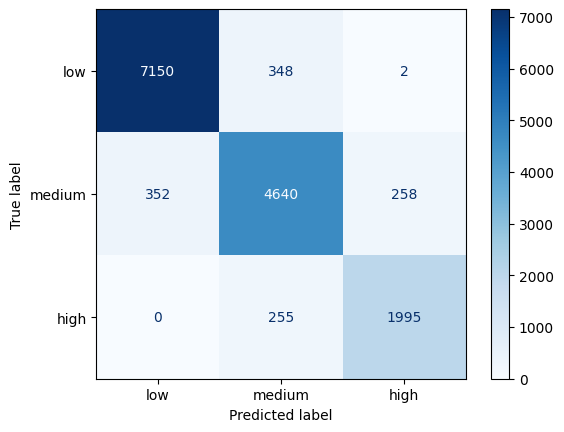

In [480]:
# Evaluacion del modelo
metrics = []

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred, labels=nombreClases)

conf_matrix_display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=nombreClases)
conf_matrix_display.plot(cmap='Blues')
f1 = f1_score(y_test, y_pred, average='weighted')
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
sensitivity = sensitivity_score(y_test, y_pred, average='weighted')
specificity = specificity_score(y_test, y_pred, average='weighted')
metrics.append({
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': sensitivity,
        'F1-Score': f1,
        'Balanced Accuracy': balanced_acc,
        'Specificity': specificity,
    })

df_metrics = pd.DataFrame(metrics)

df_metrics


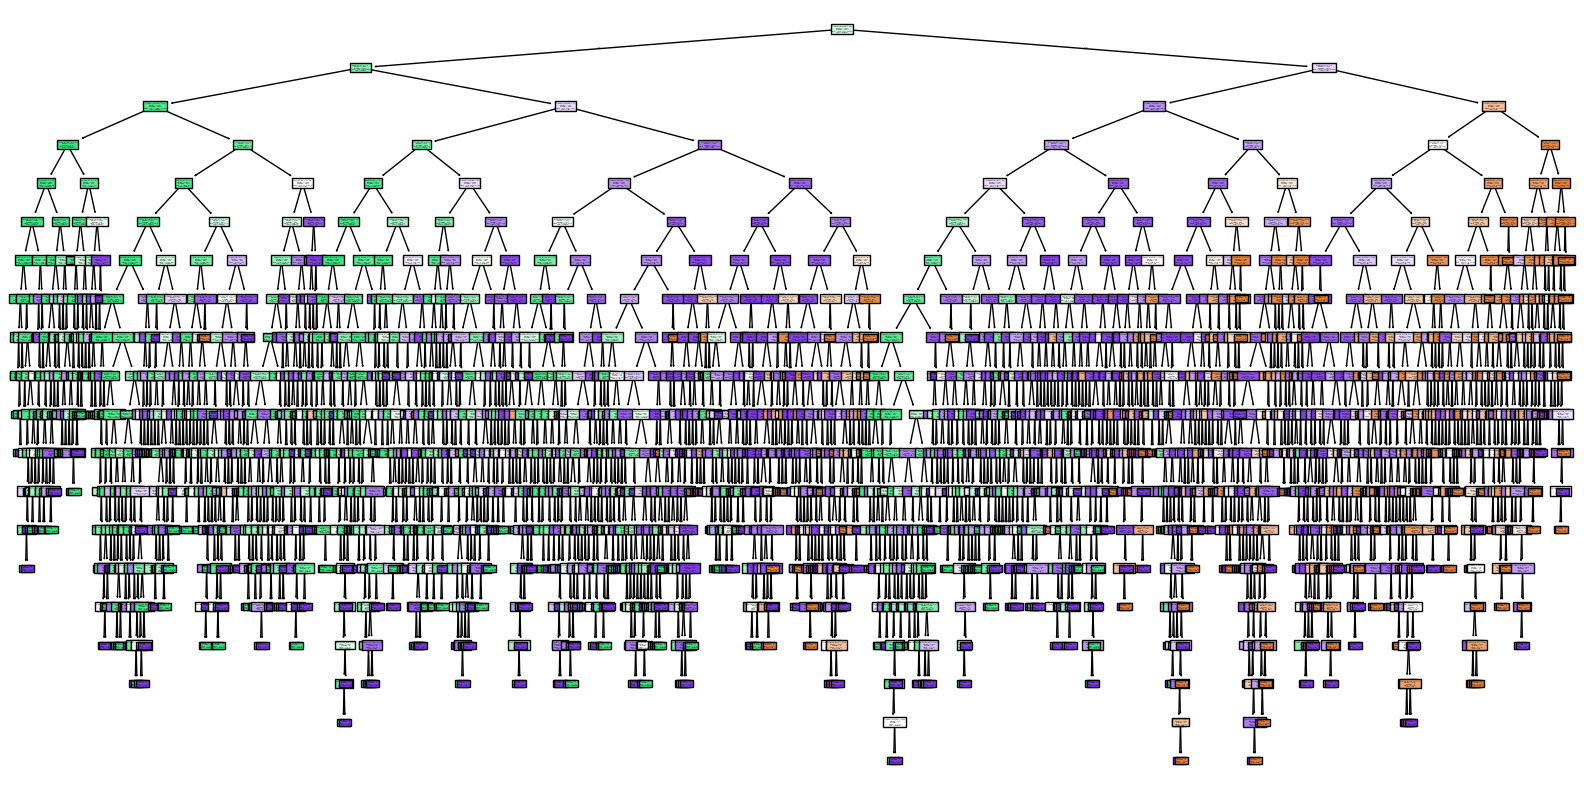

In [481]:
# Graficando el arbol
getGraph_graphviz(clf, X, nombreClases, nombreSalidaGraphviz)
getGraph_matplotlib(clf, X, nombreClases, nombreSalidaMatplotlib)